In [74]:
import pandas as pd
from matplotlib.pyplot import *
from scipy import stats
import seaborn as sns

In [75]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [76]:
summary = pd.read_csv('stan/outputs/summaries/results_20250815154906.csv', index_col=0)
#summary = pd.read_csv('stan/outputs/summaries_30/results_20250804212421.csv', index_col=0) # prior on m_0 -> 30
#summary = pd.read_csv('stan/outputs/summaries_30/results_20250804214456.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-27494.400000,1.491370,65.297500,64.344800,-27602.200000,-27494.900000,-27384.900000,1919.22,3713.90,1.00165
z_m_0_15[1],0.115055,0.000572,0.021728,0.021839,0.079253,0.114889,0.150880,1462.85,2773.69,1.00533
z_m_0_15[2],0.099505,0.000514,0.022336,0.022173,0.063241,0.099115,0.136588,1904.16,2982.67,1.00313
z_m_0_15[3],0.116751,0.000444,0.022452,0.022490,0.080319,0.116716,0.153391,2578.17,4032.47,1.00260
z_m_0_15[4],0.101043,0.000479,0.022759,0.022663,0.063305,0.101099,0.138859,2286.22,4487.77,1.00314
...,...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.513938,0.001164,0.153526,0.153864,0.260301,0.515932,0.767961,17576.90,7907.20,1.00091
delta_avg_log_var_s_1322[36],0.621292,0.001134,0.153181,0.152486,0.370653,0.620708,0.875096,18693.40,8183.89,1.00239
delta_avg_log_var_s_1322[37],0.728946,0.001226,0.158177,0.158565,0.469740,0.728784,0.990862,16993.90,7875.83,1.00060
delta_avg_log_var_s_1322[38],0.491022,0.001241,0.156781,0.154829,0.236231,0.489395,0.750402,16656.40,7250.43,1.00084


In [77]:
zs = []
for x in summary.index:
    ys = x.split('[')
    if len(ys) == 1:
        zs.append(ys[0])
    else:
        ts = ys[1].split(',')
        if len(ts) == 1:
            zs.append(ys[0] + '[i]')
        else:
            zs.append(ys[0] + '[i,j]')
zs = set(zs)
zs

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1139[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1238[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_1337[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1139[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1238[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_1337[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_

In [78]:
summary.loc[['sqrt_mse_15[10]', 'log_var_0_15[1]', 'sigma_0_15[10]', 'var_0_15[10]']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sqrt_mse_15[10],2.074960,0.001292,0.103575,0.102603,1.910970,2.071810,2.252900,6470.82,7627.93,1.00065
log_var_0_15[1],0.661808,0.001270,0.099354,0.099792,0.497429,0.661657,0.825159,6158.44,7280.20,1.00043
sigma_0_15[10],2.059810,0.001251,0.101950,0.101447,1.897770,2.056240,2.233830,6676.91,7692.00,1.00042
var_0_15[10],4.253220,0.005186,0.422360,0.415499,3.601530,4.228090,4.989980,6676.92,7692.00,1.00043


In [79]:
summary.loc[['tau', 'nu']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
tau,1.304630,0.000684,0.037543,0.037087,1.242800,1.304420,1.367210,3034.73,5912.41,1.00188
nu,0.228372,0.000140,0.008668,0.008591,0.214189,0.228335,0.242764,3894.44,5778.55,1.00147


In [80]:
( summary.R_hat > 1.01 ).mean()

0.0

In [81]:
summary[summary.R_hat>1.01]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat


In [82]:
summary.loc[[f'sigma_0_15[{i}]' for i in range(1,17)] ] #
#summary.loc[['sigma_0_15', 'sigma_0_30'] ] #

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma_0_15[1],1.39394,0.000886,0.069281,0.069304,1.28238,1.39212,1.51071,6158.42,7280.20,1.00043
sigma_0_15[2],1.69806,0.001020,0.082417,0.080831,1.56693,1.69633,1.83806,6551.84,7989.80,1.00051
sigma_0_15[3],2.02605,0.001222,0.098506,0.098163,1.87076,2.02180,2.19413,6523.10,7256.87,1.00137
sigma_0_15[4],1.92997,0.001228,0.095072,0.094338,1.77763,1.92608,2.09182,6030.80,7114.82,1.00058
sigma_0_15[5],1.95852,0.001143,0.096797,0.097703,1.80188,1.95676,2.12055,7216.29,8171.93,1.00088
sigma_0_15[6],2.08522,0.001283,0.101438,0.100305,1.92468,2.08186,2.25757,6303.12,7948.07,1.00090
sigma_0_15[7],2.04250,0.001239,0.098563,0.099097,1.88246,2.04020,2.20701,6369.68,7476.38,1.00138
sigma_0_15[8],2.00910,0.001197,0.096579,0.095961,1.85291,2.00705,2.17241,6554.78,7343.01,1.00008
sigma_0_15[9],2.03890,0.001242,0.099149,0.100795,1.88078,2.03622,2.20665,6437.35,7745.32,1.00070
sigma_0_15[10],2.05981,0.001251,0.101950,0.101447,1.89777,2.05624,2.23383,6676.91,7692.00,1.00042


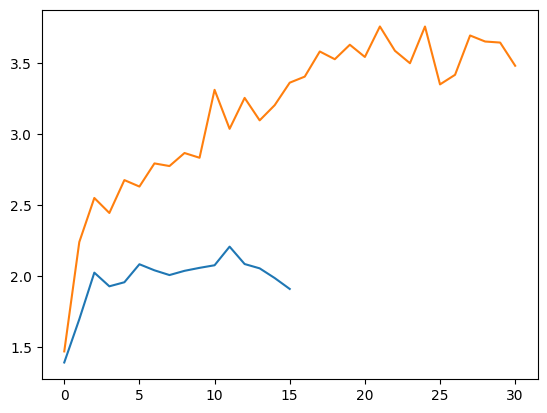

In [83]:
plot( summary.loc[[f'sigma_0_15[{i}]' for i in range(1,16+1)] ].Mean.values )
plot( summary.loc[[f'sigma_0_30[{i}]' for i in range(1,31+1)] ].Mean.values )

In [84]:
summary.loc[[f'sigma_s_15[{sid},{i}]' for i in range(1,17) for sid in range(1,40)] ]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
"sigma_s_15[1,1]",2.06285,0.001886,0.253759,0.245007,1.692210,2.03690,2.52017,21132.1,7546.65,1.00175
"sigma_s_15[2,1]",2.40297,0.002577,0.314598,0.301783,1.937550,2.37509,2.96361,17241.5,7428.86,1.00144
"sigma_s_15[3,1]",1.84086,0.002013,0.257114,0.246223,1.470060,1.81542,2.29821,18836.7,6989.22,1.00180
"sigma_s_15[4,1]",2.59658,0.002710,0.332349,0.324044,2.108840,2.56316,3.18794,17047.8,7540.08,1.00129
"sigma_s_15[5,1]",1.12749,0.001131,0.150300,0.145717,0.907282,1.11427,1.40081,19958.8,7245.38,1.00132
...,...,...,...,...,...,...,...,...,...,...
"sigma_s_15[35,16]",1.85348,0.002145,0.271288,0.259803,1.458100,1.82721,2.34228,18876.0,7205.21,1.00024
"sigma_s_15[36,16]",1.62794,0.002085,0.270941,0.257505,1.235220,1.60057,2.12018,19745.4,6922.34,1.00075
"sigma_s_15[37,16]",1.73932,0.002243,0.281315,0.272672,1.332470,1.71077,2.23449,17577.6,7592.33,1.00078
"sigma_s_15[38,16]",1.85193,0.002415,0.305131,0.288099,1.413470,1.82018,2.40408,18552.0,7627.78,1.00061


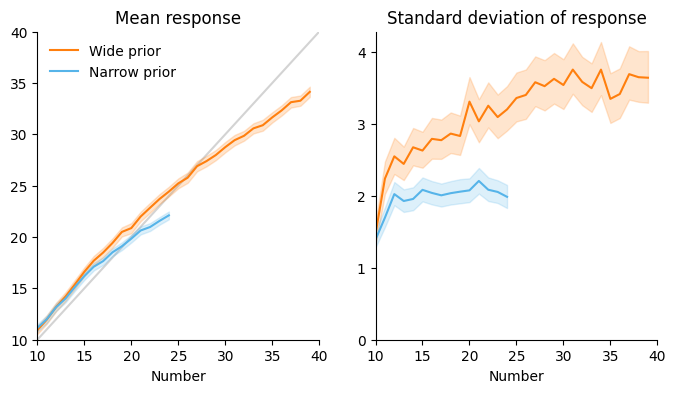

In [85]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize() + ' prior')
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                # p_pos = summary.loc[f'bin_avg_sqrt_mse_diff_pos[{i+1}]']['Mean'].squeeze()
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

In [86]:
np.arange(10, 10+W_NARROW+1)

array([10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22.,
       23., 24., 25.])

In [87]:
def norm(x, mu, w):
    return np.exp(-.5*((x-mu)/w)**2)

def prf(x, mu, w):
    return norm( np.log(x), np.log(mu), w )


In [88]:
def plot_prior(ax, x0, x1, v, c, zorder=None, ylabel='Probability'):
    ax.plot([x0,x1], [v, v], c=c, zorder=zorder)
    ax.plot([x0,x0], [0, v], c=c, ls=':', zorder=zorder)
    ax.plot([x1,x1], [0, v], c=c, ls=':', zorder=zorder)
    if ylabel:
        ax.set_ylabel(ylabel)

In [89]:
from matplotlib.patches import ConnectionPatch

7 10 13 16 19 22 25 

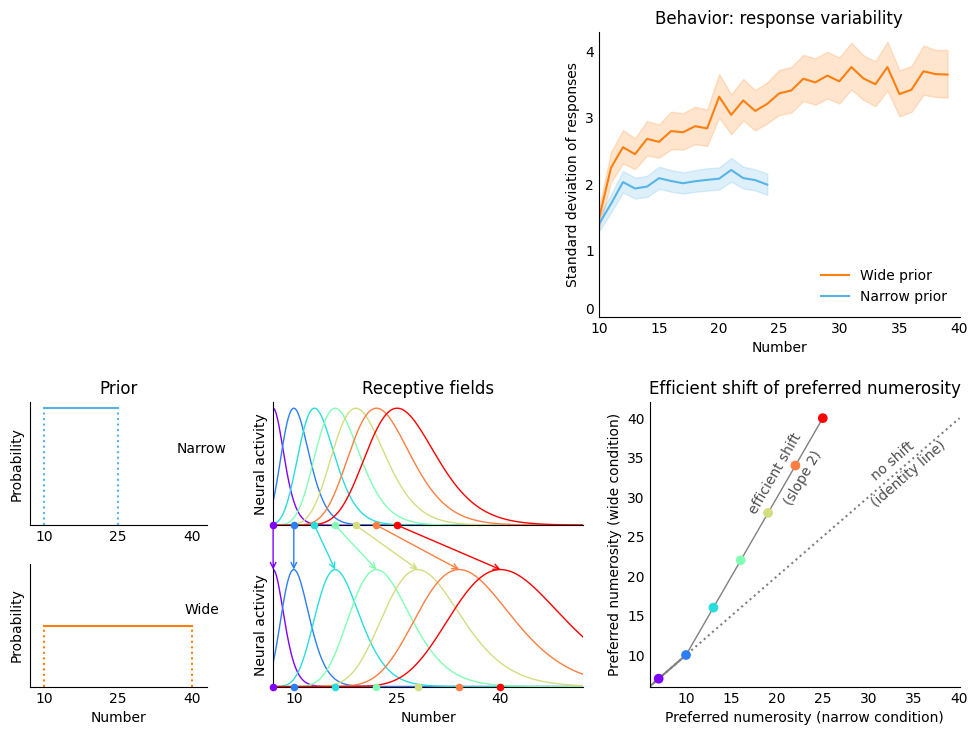

In [90]:
fig, axs = subplots(nrows=3, ncols=3, figsize=(12,8.5), width_ratios=[8,14,14], height_ratios=[2.7,1,1])

gs = axs[0, 0].get_gridspec()
for ax in axs[1:, 2]:
    ax.remove()
axbig = fig.add_subplot(gs[1:, 2])
axs[0,0].remove()
axs[0,1].remove()

axPriorN = axs[1,0]
axPriorW = axs[2,0]
axRF_N = axs[1,1]
axRF_W = axs[2,1]

#axStdDev = axs[0,2]
axs[0,2].remove()
gs_top = GridSpec(nrows=2, ncols=10, hspace=.3)
axStdDev = fig.add_subplot(gs_top[0, 6:])
#axStdDev = fig.add_subplot( 2, 2, 2 )

#### Std Dev subjects
plot_subjects_stan(ax_m=None, ax_sigma=axStdDev)
#axs[0].legend(loc='upper left')
#axs[0].set_title('Mean response')
axStdDev.set_title('Behavior: response variability')
axStdDev.set_xlim(10,40)
axStdDev.set_ylim(0,None)
axStdDev.set_yticks([0,1,2,3,4])
axStdDev.set_xlabel('Number') # $x$
axStdDev.set_ylabel('Standard deviation of responses') # $\hat x$
axStdDev.legend(loc='lower right', )
axStdDev.get_yticklabels()[0].set_verticalalignment('bottom')
#####

sigma = .2
xx = np.linspace(5, 56, 500)
no_change = False
pref_nums = np.arange(7, 26, 3)
num_tcs = len(pref_nums)
cmap = cm.rainbow

### priors
plot_prior(axPriorN, 10, 25, 1./16, c=COLORS_COND[NARROW])
plot_prior(axPriorW, 10, 40, 1./31, c=COLORS_COND[WIDE])
axPriorW.set_ylim( *axPriorN.get_ylim() )
axPriorW.set_xlabel('Number')
axPriorN.set_title('Prior')
axPriorN.text(42,1.2/31,'Narrow', ma='center', ha='center')
axPriorW.text(42,1.2/31,'Wide', ma='center', ha='center')
for ax in axs[1:,0]: ax.set_xlim(7,43)

### receptive fields
pref_nums_w = []
for ii,mode in enumerate( pref_nums ):
    #print(mode)
    c = cmap( (mode-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ) #cmap(ii/num_tcs)
    axRF_N.plot(xx, prf(xx, mode, sigma), lw=1, c=c)
    axRF_N.scatter(x=mode, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[0,1], 10, 25, .5, c=COLORS_COND[NARROW], ylabel=None, zorder=-1000)
    mode_w = mode if no_change or mode <= 10 else ( 10 + 2*(mode-10) )
    pref_nums_w.append(mode_w)
    sigma_w = sigma #if no_change else np.sqrt(2)*sigma
    axRF_W.plot(xx, prf(xx, mode_w, sigma_w), lw=1, c=c)
    axRF_W.scatter(x=mode_w, y=0, zorder=1000, clip_on=False, color=c, s=20)
    #plot_prior(axs[1,1], 10, 40, .25, c=COLORS_COND[WIDE], ylabel=None, zorder=-1000)
for ax in axs[1:,:2].flatten():
    ax.set_yticks([])
    ax.set_ylim(0,None); #ax.set_xlim(10,40)
    #ax.set_xticks([10,15,20,25,30,35,40])
    ax.set_xticks([10,25,40])
axRF_N.set_xticklabels([])
axRF_N.set_title('Receptive fields') #('Tuning curves')
axRF_N.set_ylabel('Neural activity')
axRF_W.set_ylabel('Neural activity')
axRF_W.set_xlabel('Number')
for ax in axs[1:,1]: ax.set_xlim(7,52)

#for pref_n in [10, 15, 20, 25]:
#for pref_n in pref_nums[1:]:
for pref_n in pref_nums[:]:
    print(pref_n, end=' ')
    pref_w = pref_n if no_change or pref_n <= 10 else ( 10 + 2*(pref_n-10) )
    c = cmap( (pref_n-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) )
    con = ConnectionPatch(xyA=(pref_n, 0), xyB=(pref_w, prf(pref_w,pref_w,sigma)), coordsA='data', coordsB='data',
            axesA=axRF_N, axesB=axRF_W, color=c, arrowstyle='->', linewidth=1, zorder=100)
    axRF_W.add_artist(con)

axbig.scatter(pref_nums, pref_nums_w, c=cmap( (pref_nums-pref_nums[0])/(pref_nums[-1]-pref_nums[0]) ), zorder=1000, clip_on=False)
axbig.plot([5,10], [5,10], c='grey')
axbig.axline([10,10], slope=1, ls=':', c='grey')
axbig.set_xlim(6, 40) # 28)
axbig.plot([10,25],[10,40], c='grey', lw=1)
#axbig.text(29.25, 29.8, 'no adaptation\n(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 30+2.15, 'no shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
axbig.text(30, 28.8, '(identity line)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(1)), transform_rotates_text=True) # 34
# axbig.annotate('efficient adaptation\n(slope = 2)', xy=(20,30), xytext=(15, 35), c=(.2,)*3, ma='center', ha='center',
#                arrowprops=dict(arrowstyle="->", connectionstyle="arc", color='grey'), ) # rotation=0, 
axbig.text(16.6, 28, 'efficient shift', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.text(20.5, 29, '(slope 2)', c=(.3,)*3, ma='center', rotation=np.degrees(np.arctan(2)), transform_rotates_text=True)
axbig.set_ylim(6, 42)
axbig.set_xlabel('Preferred numerosity (narrow condition)')
axbig.set_ylabel('Preferred numerosity (wide condition)')
axbig.set_title('Efficient shift of preferred numerosity')
axbig.set_xticks([10,15,20,25,30,35,40])
fig.subplots_adjust(wspace=.25)

sns.despine(fig=fig)
for ax in fig.axes:
    ax.tick_params(axis='both', length=0)

#fig.savefig('figures/subjs_stddev_priors_effcod.pdf', bbox_inches='tight')

# fMRI-derived estimates

In [59]:
#summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804221241.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
summary_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804230132.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
summary_fmri

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-53976.400000,1.150510,48.052000,-54054.500000,-53977.100000,-53896.700000,1744.38,2.7466,1.007210
z_m_0_15[1],0.347750,0.000103,0.013147,0.326184,0.347822,0.369634,16156.90,25.4396,0.999686
z_m_0_15[2],0.295590,0.000112,0.013020,0.273958,0.295619,0.316875,13554.10,21.3415,0.999810
z_m_0_15[3],0.252856,0.000107,0.013107,0.231918,0.252739,0.274820,15115.70,23.8002,0.999593
z_m_0_15[4],0.198327,0.000100,0.012127,0.178266,0.198420,0.218509,14644.50,23.0583,0.999623
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.304574,0.000285,0.033352,0.249837,0.304637,0.359477,13720.00,21.6026,0.999678
delta_avg_log_var_s_1322[36],0.305053,0.000279,0.033348,0.250431,0.304978,0.360579,14292.00,22.5034,0.999645
delta_avg_log_var_s_1322[37],0.305221,0.000274,0.033189,0.251288,0.305200,0.360276,14657.60,23.0790,0.999489
delta_avg_log_var_s_1322[38],0.304864,0.000284,0.033306,0.250051,0.305037,0.359334,13730.00,21.6184,0.999471


In [60]:
( summary_fmri.R_hat > 1.01 ).mean()

5.600672080649678e-05

In [61]:
summary_fmri[summary_fmri.R_hat>1.01]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188


In [ ]:
summary_fmri.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,0.441794,0.008213,0.240245,0.052657,0.443699,0.832721,855.66852,1.347282,1.019188
nu,0.006775,0.000063,0.005135,0.000492,0.005775,0.016620,6570.43212,10.345394,1.000549
sigma_0_15[1],9.204450,0.002182,0.272549,8.768300,9.197260,9.661690,15601.60000,24.565300,0.999840
sigma_0_15[10],9.302670,0.002277,0.283145,8.850170,9.296870,9.777000,15462.50000,24.346200,0.999658
sigma_0_30[1],10.817800,0.003681,0.468077,10.078300,10.799400,11.619700,16173.70000,25.466100,1.000100
sigma_0_30[10],10.504400,0.003394,0.426018,9.835980,10.488700,11.221000,15751.70000,24.801700,0.999799


In [71]:
summary.loc[['tau', 'nu', 'sigma_0_15[1]', 'sigma_0_15[10]', 'sigma_0_30[1]', 'sigma_0_30[10]']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
tau,1.30472,0.000730,0.037610,1.24341,1.30383,1.36754,2690.12000,4.37988,1.00309
nu,0.22874,0.000140,0.008600,0.21463,0.22877,0.24292,3852.58381,6.27252,1.00241
sigma_0_15[1],1.39327,0.000967,0.070394,1.28122,1.39188,1.51113,5294.46000,8.62009,1.00056
sigma_0_15[10],2.06255,0.001342,0.101933,1.89974,2.05994,2.23650,5770.30000,9.39483,1.00059
sigma_0_30[1],1.47001,0.001180,0.096615,1.31683,1.46669,1.63495,6698.73000,10.90640,1.00054
sigma_0_30[10],2.83089,0.001995,0.168354,2.56815,2.82320,3.12039,7123.87000,11.59860,1.00082


NameError: name 'summary_fmri' is not defined

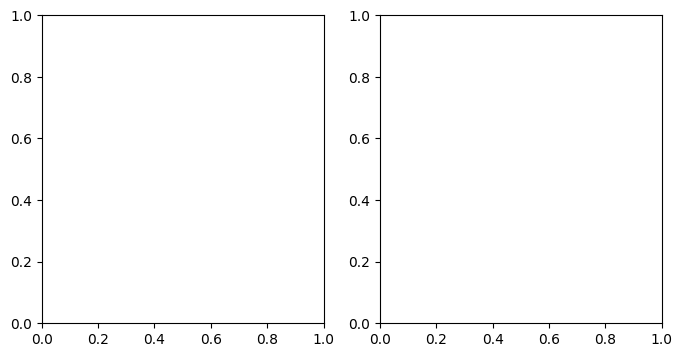

In [73]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_fmri_subjects_stan(ax_m, ax_sigma):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = {'m_0': ax_m, 'sigma_0': ax_sigma}[qty]
        if ax is None:
            continue
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, 10 + {NARROW: W_NARROW, WIDE: W_WIDE}[cond], 1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+1):
                r = summary_fmri.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)
    if False:
        ### TESTS ###
            print('mean', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_m_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = summary_fmri.loc[f'bin_avg_m_0[2,{i+1}]']['Mean']+1  #summary_pooled_dfs[(experiment, nb_bins)].loc[conditions[1], 'response_avg'][i] + 1
                if pv<.001:
                    axs[ie,0].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nvariance', end=' ')
            for i in range(nb_bins):
                p_pos = summary_fmri.loc[f'bin_avg_sigma_diff_pos[{i+1}]']['Mean'].squeeze()
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = max(summary_fmri.loc[f'bin_avg_sigma_0[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sigma_0[1,{i+1}]']['Mean']) + [.5,.3][ie]
                if pv<.001:
                    axs[ie,1].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print('\nmse', end=' ')
            # computed on server
            p_pos_priors = np.array([0.4113, 1.    , 1.    , 0.1961, 0.    , 0.    ])
            p_pos_stakes = np.array([1.    , 1.    , 1.    , 0.9938, 0.    , 0.    ])
            for i in range(nb_bins):
                p_pos = (p_pos_priors if experiment==PRIORS else p_pos_stakes)[i]
                pv = .5 - abs(.5-p_pos)
                print(f'{i}:{pv}, ', end=' ')
                xx = xs_bins[i]
                yy = min(summary_fmri.loc[f'bin_avg_sqrt_mse[2,{i+1}]']['Mean'],summary_fmri.loc[f'bin_avg_sqrt_mse[1,{i+1}]']['Mean']) - .5
                if pv<.001:
                    axs[ie,2].text(xx, yy, '*', fontsize=10, ha='center', va='center')
            print()

plot_fmri_subjects_stan(axs[0], axs[1])
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)